In [53]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import os 
import zipfile
import urllib.request


from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
        accuracy_score,roc_auc_score,precision_score,
        recall_score,f1_score,matthews_corrcoef,
        confusion_matrix,classification_report
)


###### Loading the data 
# Create data directory
os.makedirs("../data/initial/", exist_ok=True)

# UCI dataset URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank.zip"
zip_path = "../data/initial/bank.zip"

# Download dataset
urllib.request.urlretrieve(url, zip_path)
print("Dataset downloaded successfully!")

# Extract zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("../data/initial/")

print("Dataset extracted successfully!")



Dataset downloaded successfully!
Dataset extracted successfully!


In [54]:
# Load dataset of the full set file 
df = pd.read_csv("../data/initial/bank-full.csv", sep=";")
df_val=pd.read_csv("../data/initial/bank.csv", sep=";")


In [55]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [56]:
df_val.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [57]:
df.shape

(45211, 17)

In [58]:
df_val.shape

(4521, 17)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [60]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [61]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [62]:
df_val.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

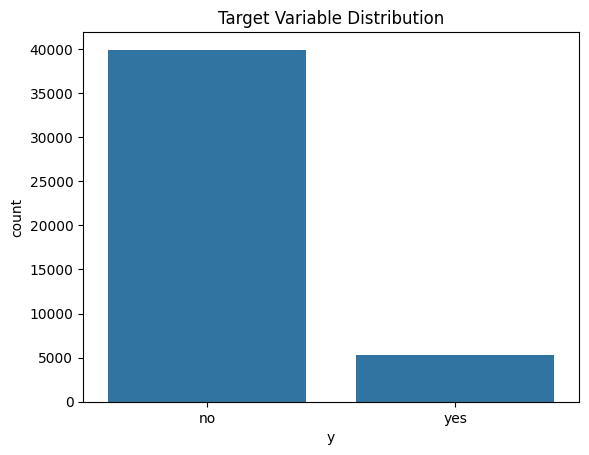

In [63]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

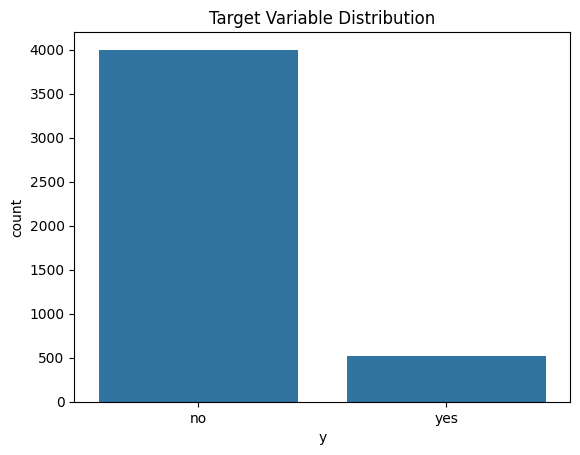

In [64]:
sns.countplot(x='y', data=df_val)
plt.title("Target Variable Distribution")
plt.show()

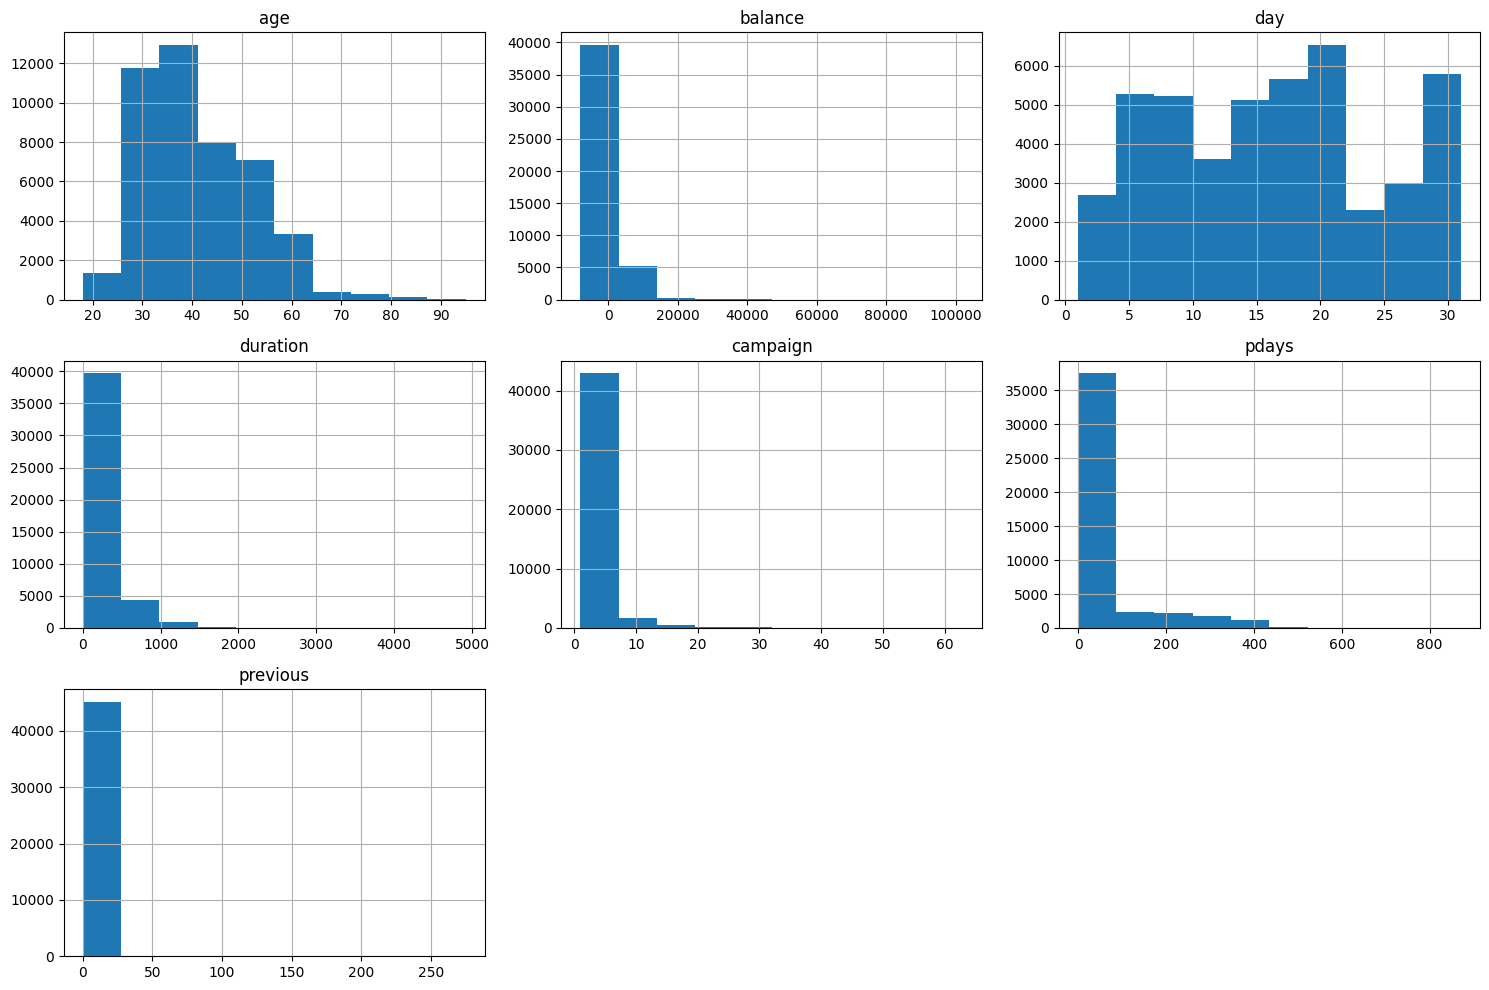

In [65]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()


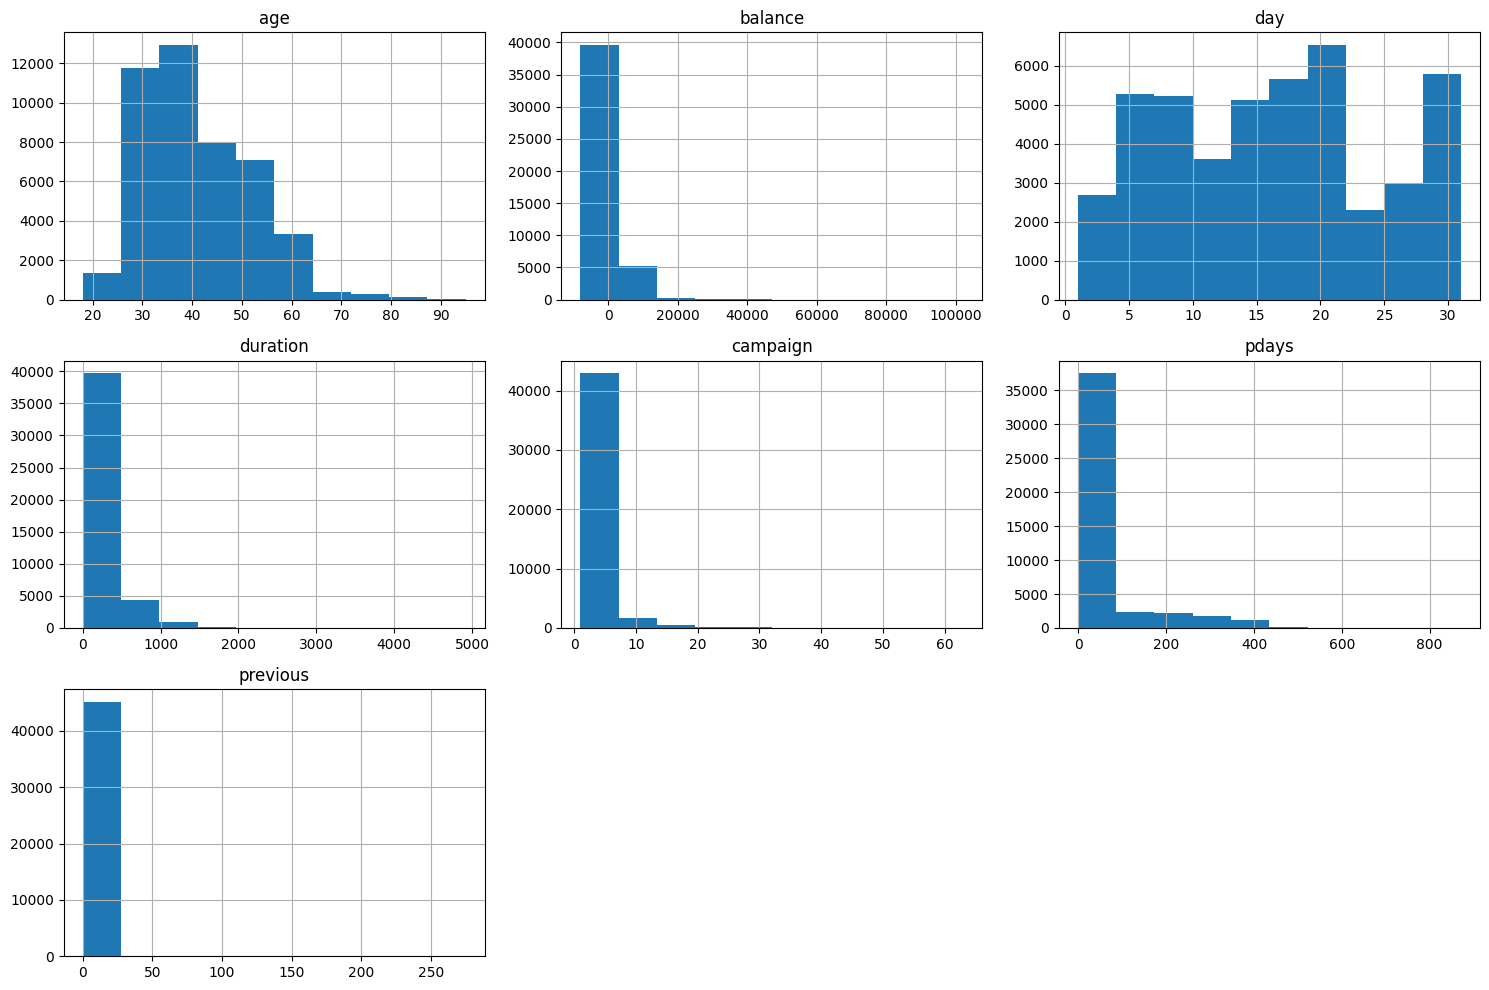

In [66]:
num_cols = df_val.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

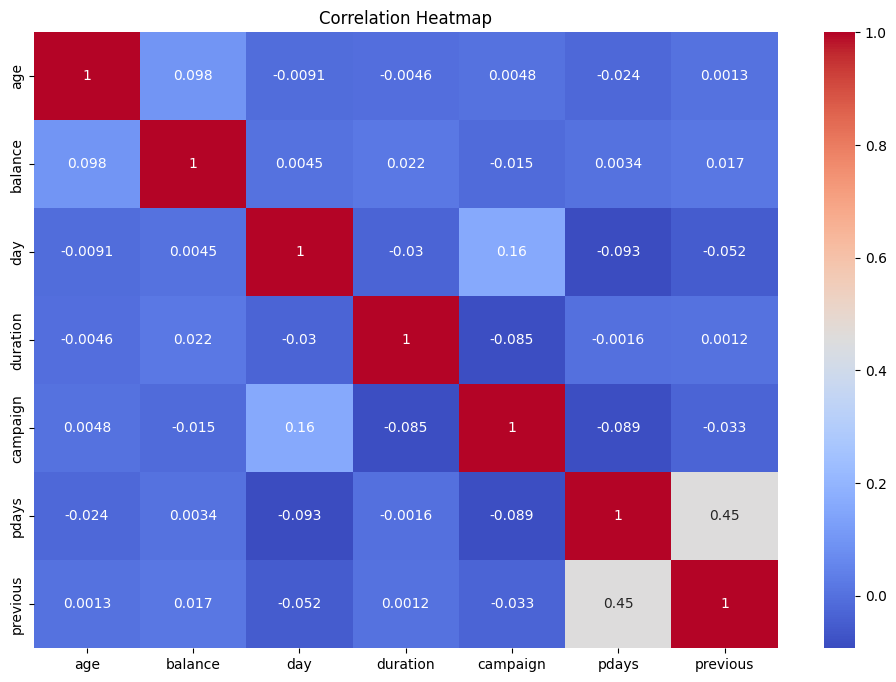

In [67]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

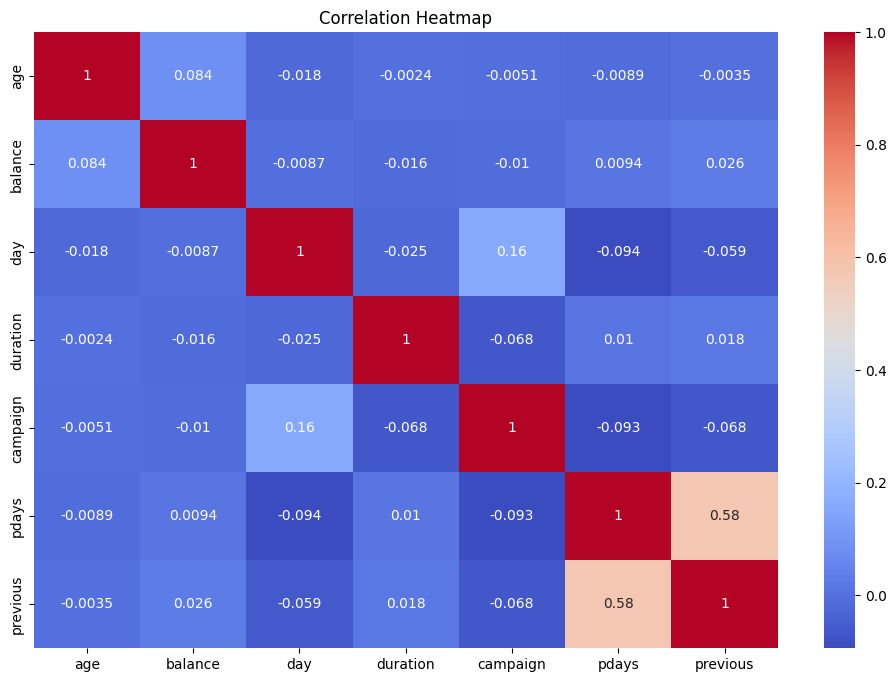

In [68]:
plt.figure(figsize=(12, 8))
sns.heatmap(df_val[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [69]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

In [70]:
df_val['y'] = df_val['y'].map({'yes': 1, 'no': 0})

In [71]:
categorical_cols = df.select_dtypes(include=['object']).columns

In [72]:
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [73]:
#df_train_test, df_val = train_test_split(
#    df, test_size=0.2, random_state=42, stratify=df['y']
#)

In [74]:
#df_train, df_test = train_test_split(
#    df_train_test, test_size=0.2, random_state=42, stratify=df_train_test['y']
#)

In [75]:
#df_train.to_csv("data/bank_train.csv", index=False)
#df_test.to_csv("data/bank_test.csv", index=False)
#df_val.to_csv("data/bank_val.csv", index=False)

#print("Files created: bank_train.csv, bank_test.csv, bank_val.csv")

In [76]:
#X = df.drop('y', axis=1)
#y = df['y']

In [77]:
#X_train, X_test, y_train, y_test = train_test_split(
#    X, y, test_size=0.2, random_state=42, stratify=y
#)


In [78]:
#scaler = StandardScaler()
#X_train_scaled = scaler.fit_transform(X_train)
#X_test_scaled = scaler.transform(X_test)